# Results Plots Script

## Initializations

### Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Constants

In [2]:
BASE_PATH = "./results/adult/"
ALGOS = ["perturbation", "oka", "kmember", "classic_mondrian", "datafly"]
K = [2] + list(range(5, 101, 5))
MARKERS = {
    "perturbation": "$p$",
    "oka": "$o$",
    "kmember": "$k$",
    "classic_mondrian": "$m$",
    "datafly": "$d$",
}
COLORS = {
    "sample": "tab:green",
    "perturbation": "tab:olive",
    "oka": "tab:blue",
    "kmember": "tab:red",
    "classic_mondrian": "tab:purple",
    "datafly": "tab:brown",
}

## Plots

### Data Utility

In [3]:
def get_ut_score(results_df):
    return results_df.set_index("metric").T.to_dict(orient="records")[0]


def get_all_ut_scores(path, all_k):
    all_ut_scores = []
    for k in all_k:
        all_ut_scores.append(get_ut_score(pd.read_csv(f"{path}/k_{k}/results_ut.csv")))
    return all_ut_scores

In [4]:
sample_ut_scores = get_ut_score(pd.read_csv(f"{BASE_PATH}/sample/results_ut.csv"))
all_algos_ut_scores = {}
for algo in ALGOS:
    all_algos_ut_scores[algo] = get_all_ut_scores(f"{BASE_PATH}/{algo}", K)

#### $C_{AVG}$

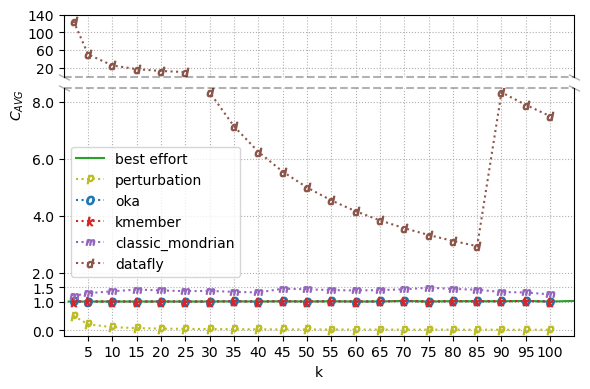

In [5]:
fig, (baseline_axis, axis) = plt.subplots(
    2, 1, figsize=[6, 4], sharex=True, gridspec_kw={"height_ratios": [2, 8]}
)
metric = "CAVG"

sample_scores = (
    [1] + [3000 / (int(3000 / k) * k) for k in K] + [3000 / (int(3000 / 105) * 105)]
)
axis.plot([1] + K + [105], sample_scores, label="best effort", color=COLORS["sample"])

for algo in list(all_algos_ut_scores):
    axis.plot(
        K,
        [x[metric] for x in all_algos_ut_scores[algo]],
        label=algo,
        color=COLORS[algo],
        marker=MARKERS[algo],
        linestyle=":",
    )

axis.set_ylim([-0.2, 8.5])
axis.set_yticks([0, 1, 1.5, 2, 4, 6, 8])
axis.set_ylabel(r"$C_{AVG}$", loc="top")
axis.set_xlabel("k")
axis.set_xlim([0, 105])
axis.set_xticks(K[1:])
# axis.set_yticks(range(0, 1301, 100))

baseline_axis.plot(
    K,
    [float("nan")] * len(K),
    label="best effort",
    color=COLORS["sample"],
)
for algo in list(all_algos_ut_scores):
    if algo == "datafly":
        continue
    baseline_axis.plot(
        K,
        [float("nan")] * len(K),
        label=algo,
        color=COLORS[algo],
        marker=MARKERS[algo],
        linestyle=":",
    )
baseline_axis.plot(
    K[0:6],
    [x[metric] for x in all_algos_ut_scores["datafly"][0:6]],
    label="datafly",
    color=COLORS["datafly"],
    marker=MARKERS["datafly"],
    linestyle=":",
)
axis.legend(
    ncol=1,
    fontsize="medium",
)

baseline_axis.set_ylim([0, 140])
baseline_axis.set_yticks([20, 60, 100, 140])
baseline_axis.spines.bottom.set_visible(False)
baseline_axis.tick_params(bottom=False, labeltop=False)
axis.xaxis.tick_bottom()
axis.spines.top.set_visible(False)

d = -0.5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(
    marker=[(-1, -d), (1, d)],
    markersize=8,
    linestyle="--",
    alpha=0.3,
    color="k",
    mec="k",
    mew=1,
    clip_on=False,
)
axis.plot([0, 1], [1, 1], transform=axis.transAxes, **kwargs)
baseline_axis.plot([0, 1], [0, 0], transform=baseline_axis.transAxes, **kwargs)
axis.grid(linestyle=":")
baseline_axis.grid(linestyle=":")
fig.tight_layout(h_pad=0)

fig.savefig(
    f"./figs/result_ut_CAVG.png", dpi=150, bbox_inches="tight", pad_inches=0
)

#### $DM$

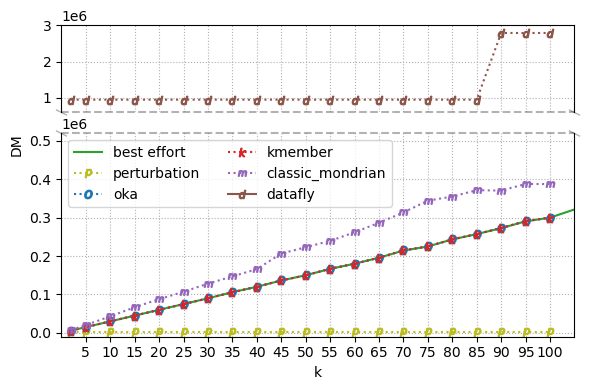

In [6]:
fig, (baseline_axis, axis) = plt.subplots(
    2, 1, figsize=[6, 4], sharex=True, gridspec_kw={"height_ratios": [3, 7]}
)
metric = "DM"
n = 3000
sample_scores = [
    ((int(n / k) - n % k) * k**2) + ((n % k) * (k + 1) ** 2) for k in K + [105]
]
axis.plot(K + [105], sample_scores, label="best effort", color=COLORS["sample"])

for algo in list(all_algos_ut_scores):
    if algo == "datafly":
        axis.plot(
            K,
            [float("nan")] * len(K),
            label=algo,
            color=COLORS[algo],
            marker=MARKERS[algo],
        )
        continue
    axis.plot(
        K,
        np.array([x[metric] for x in all_algos_ut_scores[algo]]),
        label=algo,
        color=COLORS[algo],
        marker=MARKERS[algo],
        linestyle=":",
    )

axis.set_ylim([-10000, 0.52e6])
axis.set_yticks(np.arange(0, 0.52e6, 0.1e6))
axis.ticklabel_format(axis="y", style="sci", scilimits=(6, 6))

axis.set_ylabel("DM", loc="top")
axis.set_xlabel("k")
axis.set_xlim([0, 105])
axis.set_xticks(K[1:])

baseline_axis.plot(
    K,
    [float("nan")] * len(K),
    label="best effort",
    color=COLORS["sample"],
)
for algo in list(all_algos_ut_scores):
    if algo == "datafly":
        continue
    baseline_axis.plot(
        K,
        [float("nan")] * len(K),
        label=algo,
        color=COLORS[algo],
        marker=MARKERS[algo],
        linestyle=":",
    )
baseline_axis.plot(
    K,
    np.array([x[metric] for x in all_algos_ut_scores["datafly"]]),
    label="datafly",
    color=COLORS["datafly"],
    marker=MARKERS["datafly"],
    linestyle=":",
)
axis.legend(
    ncol=len(ALGOS) / 2,
    fontsize="medium",
)

baseline_axis.set_ylim([0.6e6, 3e6])
baseline_axis.spines.bottom.set_visible(False)
baseline_axis.tick_params(bottom=False, labeltop=False)
axis.xaxis.tick_bottom()
axis.spines.top.set_visible(False)
baseline_axis.ticklabel_format(axis="y", style="sci", scilimits=(6, 6))

d = -0.5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(
    marker=[(-1, -d), (1, d)],
    markersize=8,
    linestyle="--",
    alpha=0.3,
    color="k",
    mec="k",
    mew=1,
    clip_on=False,
)
axis.plot([0, 1], [1, 1], transform=axis.transAxes, **kwargs)
baseline_axis.plot([0, 1], [0, 0], transform=baseline_axis.transAxes, **kwargs)
axis.grid(linestyle=":")
baseline_axis.grid(linestyle=":")
fig.tight_layout(h_pad=0)

fig.savefig(f"./figs/result_ut_DM.png", dpi=150, bbox_inches='tight', pad_inches=0)

#### $NCP$

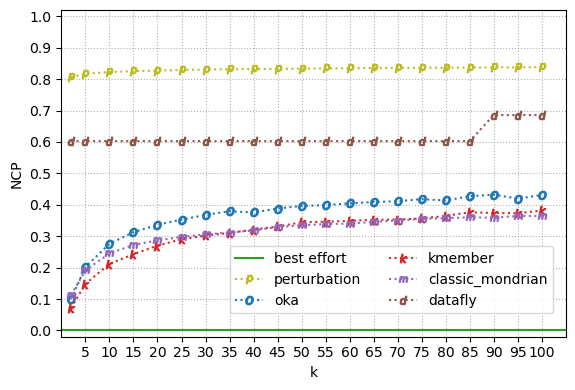

In [7]:
fig, axis = plt.subplots(1, 1, figsize=[6, 4])

baseline = [0] * len([0] + K + [105])
axis.plot(
    [0] + K + [105],
    baseline,
    label="best effort",
    color=COLORS["sample"],
)

for algo in list(all_algos_ut_scores):
    axis.plot(
        K,
        [x["IL"] for x in all_algos_ut_scores[algo]],
        label=algo,
        color=COLORS[algo],
        marker=MARKERS[algo],
        linestyle=":",
    )

axis.legend(
    ncol=len(ALGOS) / 2,
    fontsize="medium",
    bbox_to_anchor=(0.32, 0.05),
)
axis.set_ylim([-0.02, 1.02])
axis.set_ylabel("NCP")
axis.set_xlabel("k")
axis.set_xlim([0, 105])
axis.set_xticks(K[1:])
axis.set_yticks(np.arange(0, 1.05, 0.1))
axis.grid(linestyle=":")
fig.tight_layout(h_pad=0)

fig.savefig(f"./figs/result_ut_NCP.png", dpi=150, bbox_inches='tight', pad_inches=0.015)

### ML Classification Results

In [8]:
def get_f1_score(results_df):
    return (
        results_df[["model", "f1_score"]]
        .set_index("model")
        .T.to_dict(orient="records")[0]
    )


def get_all_validation_f1_scores(path, all_k):
    all_f1_scores = []
    for k in all_k:
        all_f1_scores.append(
            get_f1_score(pd.read_csv(f"{path}/k_{k}/results_ml_validation.csv"))
        )
    return all_f1_scores

In [9]:
all_algos_validation_f1_scores = {}
for algo in ALGOS:
    all_algos_validation_f1_scores[algo] = get_all_validation_f1_scores(
        f"{BASE_PATH}/{algo}", K
    )

In [10]:
sample_f1_scores = get_f1_score(pd.read_csv(f"{BASE_PATH}/sample/results_ml.csv"))

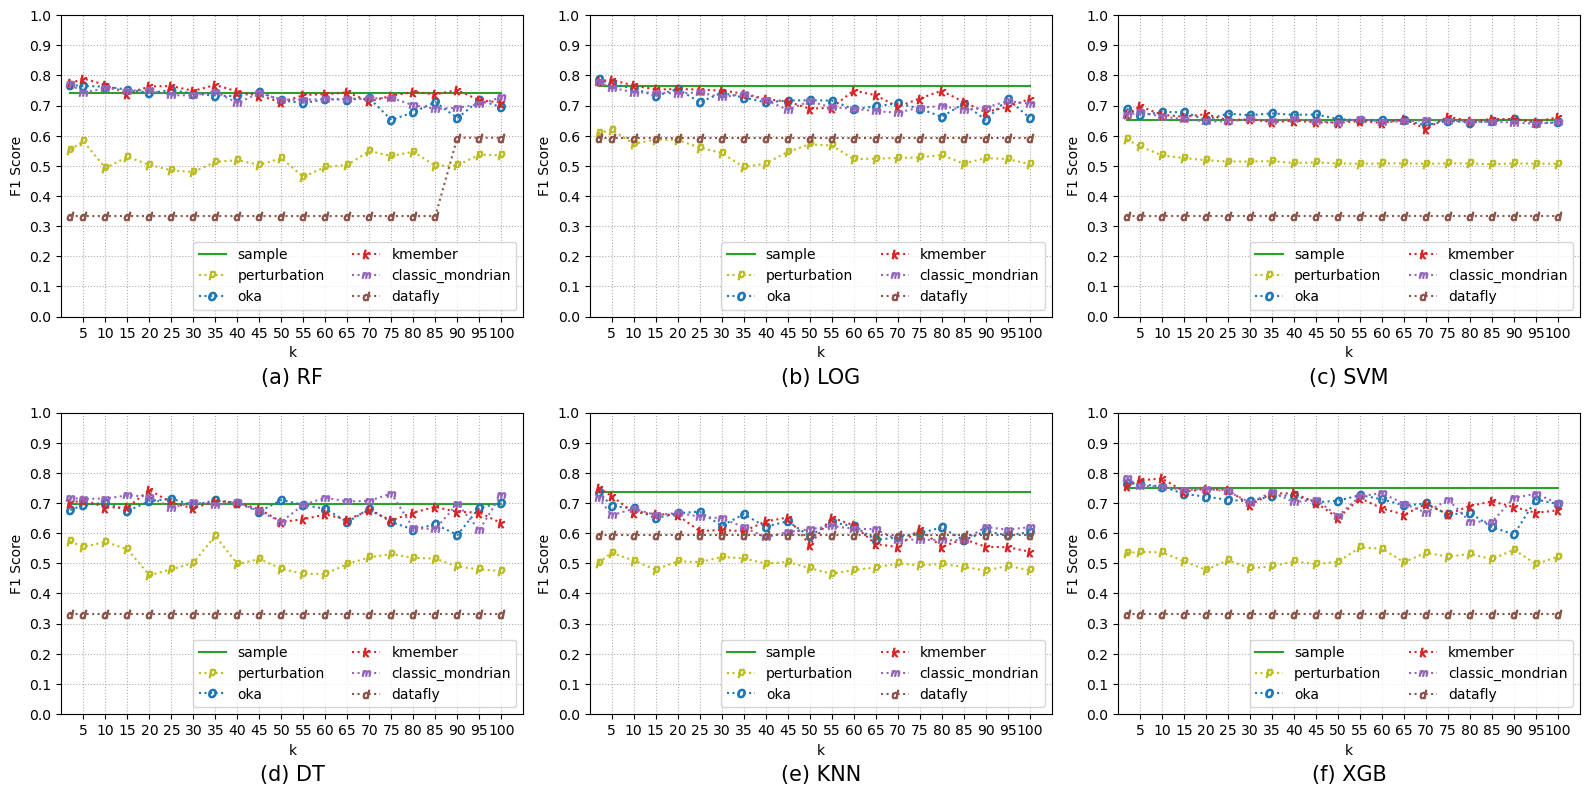

In [11]:
fig, ax = plt.subplots(2, 3, figsize=[16, 8])
codes = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]

for idx, model in enumerate(list(sample_f1_scores)):
    row = int(idx / 3)
    col = int(idx % 3)
    sample_scores = [sample_f1_scores[model]] * len(K)
    axis = ax[row][col]
    axis.plot(
        K,
        sample_scores,
        label="sample",
        color=COLORS["sample"],
    )
    for algo in all_algos_validation_f1_scores:
        axis.plot(
            K,
            [x[model] for x in all_algos_validation_f1_scores[algo]],
            label=algo,
            color=COLORS[algo],
            marker=MARKERS[algo],
            linestyle=":",
        )

    axis.legend(
        ncol=len(ALGOS) / 2,
        loc="lower right",
        fontsize="medium",
    )
    axis.set_title(f"{codes[row*3+col]} {model}", y=-0.25, fontsize=15)
    axis.set_ylim([0, 1])
    axis.set_ylabel("F1 Score")
    axis.set_xlabel(f"k")
    axis.set_xlim([0, 105])
    axis.set_xticks(K[1:])
    axis.set_yticks(np.arange(0.0, 1.1, 0.1))
    axis.grid(linestyle=":")
fig.tight_layout(h_pad=1.8)
fig.savefig(
    f"./figs/result_ml.png",
    dpi=150,
    bbox_inches="tight",
    pad_inches=0.015,
)

### Run time

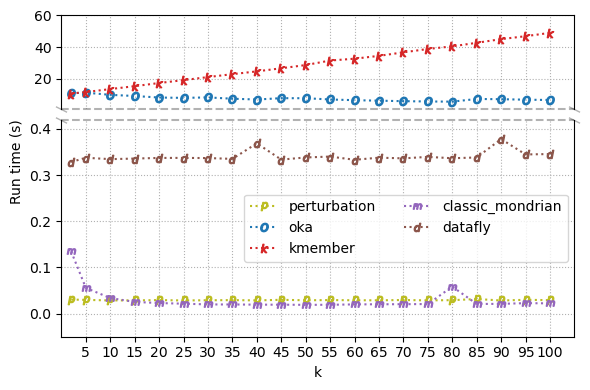

In [12]:
fig, (baseline_axis, axis) = plt.subplots(
    2, 1, figsize=[6, 4], sharex=True, gridspec_kw={"height_ratios": [3, 7]}
)
metric = "RUN_TIME"

for algo in list(all_algos_ut_scores):
    if algo in ["oka", "kmember"]:
        axis.plot(
            K,
            [float("nan")] * len(K),
            label=algo,
            color=COLORS[algo],
            marker=MARKERS[algo],
            linestyle=":",
        )
        continue
    axis.plot(
        K,
        np.array([x[metric] for x in all_algos_ut_scores[algo]]),
        label=algo,
        color=COLORS[algo],
        marker=MARKERS[algo],
        linestyle=":",
    )

axis.set_ylim([-0.05, 0.42])

axis.set_ylabel("Run time (s)", loc="top")
axis.set_xlabel("k")
axis.set_xlim([0, 105])
axis.set_xticks(K[1:])

axis.legend(
    ncol=len(ALGOS) / 2,
    fontsize="medium",
)

for algo in ["oka", "kmember"]:
    baseline_axis.plot(
        K,
        np.array([x[metric] for x in all_algos_ut_scores[algo]]),
        label=algo,
        color=COLORS[algo],
        marker=MARKERS[algo],
        linestyle=":",
    )

baseline_axis.set_ylim([1, 60])
baseline_axis.spines.bottom.set_visible(False)
baseline_axis.tick_params(bottom=False, labeltop=False)
axis.xaxis.tick_bottom()
axis.spines.top.set_visible(False)

d = -0.5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(
    marker=[(-1, -d), (1, d)],
    markersize=8,
    linestyle="--",
    alpha=0.3,
    color="k",
    mec="k",
    mew=1,
    clip_on=False,
)
axis.plot([0, 1], [1, 1], transform=axis.transAxes, **kwargs)
baseline_axis.plot([0, 1], [0, 0], transform=baseline_axis.transAxes, **kwargs)
axis.grid(linestyle=":")
baseline_axis.grid(linestyle=":")
fig.tight_layout(h_pad=0)

fig.savefig(
    f"./figs/result_run_time.png", dpi=150, bbox_inches="tight", pad_inches=0
)

### Vulnerability

In [13]:
def get_attack_result(path):
    return pd.read_csv(path)["correct"].sum().item()

In [14]:
all_attack_results = {}
for algo in ALGOS:
    all_attack_results[algo] = [
        pd.read_csv(f"{BASE_PATH}/{algo}/k_{k}/results_attack.csv")["correct"]
        .sum()
        .item()
        for k in K
    ]

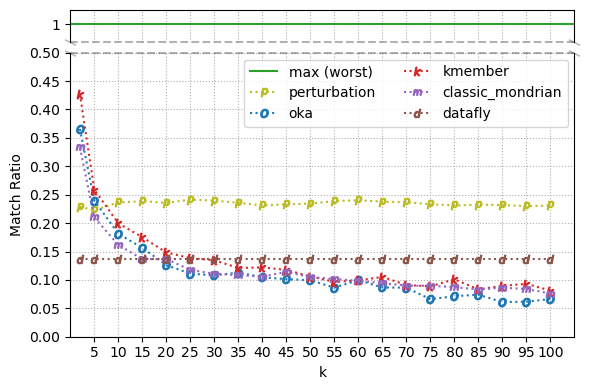

In [15]:
fig, (baseline_axis, axis) = plt.subplots(
    2, 1, figsize=[6, 4], sharex=True, gridspec_kw={"height_ratios": [1, 9]}
)

axis.plot(
    range(0, 106, 1),
    [float("nan")] * 106,
    label="max (worst)",
    color=COLORS["sample"],
)

for algo in list(all_attack_results):
    axis.plot(
        K,
        np.array(all_attack_results[algo]) / 3000,
        label=algo,
        color=COLORS[algo],
        marker=MARKERS[algo],
        linestyle=":",
    )

axis.legend(
    ncol=len(ALGOS) / 2,
    fontsize="medium",
)
axis.set_ylim([0, 0.5])
axis.set_ylabel("Match Ratio")
axis.set_xlabel("k")
axis.set_xlim([0, 105])
axis.set_xticks(K[1:])
axis.set_yticks(np.arange(0, 0.51, 0.05))

baseline = [1] * 106
baseline_axis.plot(
    range(0, 106, 1),
    baseline,
    label="best effort",
    color=COLORS["sample"],
)

baseline_axis.set_ylim([0.88, 1.1])
baseline_axis.set_yticks([1])
baseline_axis.spines.bottom.set_visible(False)
baseline_axis.tick_params(bottom=False, labeltop=False)
axis.xaxis.tick_bottom()
axis.spines.top.set_visible(False)

d = -0.5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(
    marker=[(-1, -d), (1, d)],
    markersize=8,
    linestyle="--",
    alpha=0.3,
    color="k",
    mec="k",
    mew=1,
    clip_on=False,
)
axis.plot([0, 1], [1, 1], transform=axis.transAxes, **kwargs)
baseline_axis.plot([0, 1], [0, 0], transform=baseline_axis.transAxes, **kwargs)
axis.grid(linestyle=":")
baseline_axis.grid(linestyle=":")
fig.tight_layout(h_pad=0)

fig.savefig(
    f"./figs/result_vulnerability.png", dpi=150, bbox_inches="tight", pad_inches=0
)